# Customer Sales Analysis Report

This analysis examines customer purchasing patterns to identify top customers and create a comprehensive sales performance dashboard.

In [55]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Step 1: Data Loading and Exploration

In [56]:
# Load the sales data
sales_df = pd.read_csv('sales_data.csv')

# Display basic information about the sales data
print("SALES DATA OVERVIEW")
print("-" * 30)
print(f"\nShape: {sales_df.shape[0]} rows, {sales_df.shape[1]} columns")
print(f"\nColumn names: {list(sales_df.columns)}")
print("\nFirst 5 rows:")
sales_df.head()

SALES DATA OVERVIEW
------------------------------

Shape: 100 rows, 7 columns

Column names: ['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

First 5 rows:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [57]:
# Check data types and missing values for sales data
print("Data Types:")
print(sales_df.dtypes)
print("\n" + "-" * 30)
print("Missing Values:")
print(sales_df.isnull().sum())
print("\n" + "-" * 30)
print("Basic Statistics:")
sales_df.describe()

Data Types:
Date             str
Product          str
Quantity       int64
Price          int64
Customer_ID      str
Region           str
Total_Sales    int64
dtype: object

------------------------------
Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

------------------------------
Basic Statistics:


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [58]:
# Load customer churn data
customer_df = pd.read_csv('customer_churn.csv')

# Display basic information about customer data
print("CUSTOMER DATA OVERVIEW")
print("-" * 30)
print(f"\nShape: {customer_df.shape[0]} rows, {customer_df.shape[1]} columns")
print(f"\nColumn names: {list(customer_df.columns)}")
print("\nFirst 5 rows:")
customer_df.head()

CUSTOMER DATA OVERVIEW
------------------------------

Shape: 500 rows, 9 columns

Column names: ['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']

First 5 rows:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [59]:
# Check data types and missing values for customer data
print("Data Types:")
print(customer_df.dtypes)
print("\n" + "-" * 30)
print("Missing Values:")
print(customer_df.isnull().sum())
print("\n" + "-" * 30)
print("Basic Statistics:")
customer_df.describe()

Data Types:
CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
SeniorCitizen       int64
Churn               int64
dtype: object

------------------------------
Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

------------------------------
Basic Statistics:


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


## Step 2: Data Cleaning and Preparation

In [60]:
# Convert Date column to datetime format
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Extract date components for analysis
sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Month_Name'] = sales_df['Date'].dt.month_name()
sales_df['Day'] = sales_df['Date'].dt.day
sales_df['Day_of_Week'] = sales_df['Date'].dt.day_name()

# Verify the conversion
print("Date column converted successfully!")
print(f"Date range: {sales_df['Date'].min()} to {sales_df['Date'].max()}")
sales_df.head()

Date column converted successfully!
Date range: 2024-01-01 00:00:00 to 2024-04-09 00:00:00


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Month_Name,Day,Day_of_Week
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,January,1,Monday
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,January,2,Tuesday
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,January,3,Wednesday
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,January,4,Thursday
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,January,5,Friday


In [61]:
# Clean text data in Product column
sales_df['Product'] = sales_df['Product'].str.strip()

# Clean Region column
sales_df['Region'] = sales_df['Region'].str.strip()

# Verify unique values
print("Unique Products:", sales_df['Product'].unique())
print("\nUnique Regions:", sales_df['Region'].unique())

Unique Products: <StringArray>
['Phone', 'Headphones', 'Laptop', 'Tablet', 'Monitor']
Length: 5, dtype: str

Unique Regions: <StringArray>
['East', 'North', 'West', 'South']
Length: 4, dtype: str


## Step 3: Customer Analysis

In [62]:
# Calculate total sales per customer
customer_sales = sales_df.groupby('Customer_ID').agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum',
    'Product': 'count'
}).rename(columns={
    'Total_Sales': 'Lifetime_Value',
    'Product': 'Total_Orders',
    'Quantity': 'Total_Items_Purchased'
}).reset_index()

# Sort by lifetime value (descending)
customer_sales = customer_sales.sort_values('Lifetime_Value', ascending=False)

# Display top 10 customers
print("-" * 36)
print("TOP 10 CUSTOMERS BY LIFETIME VALUE")
print("-" * 36)
top_10_customers = customer_sales.head(10)
top_10_customers

------------------------------------
TOP 10 CUSTOMERS BY LIFETIME VALUE
------------------------------------


,Customer_ID,Lifetime_Value,Total_Items_Purchased,Total_Orders
15,CUST016,373932,9,1
6,CUST007,363870,9,1
82,CUST083,350888,8,1
72,CUST073,349510,7,1
19,CUST020,333992,8,1
83,CUST084,324144,8,1
69,CUST070,318762,9,1
4,CUST005,318680,8,1
64,CUST065,312564,7,1
27,CUST028,304465,7,1


In [63]:
# Calculate average order value for each customer
customer_sales['Average_Order_Value'] = (
    customer_sales['Lifetime_Value'] / customer_sales['Total_Orders']
)

# Display summary statistics
print("-" * 36)
print("CUSTOMER LIFETIME VALUE STATISTICS")
print("-" * 36)
print(f"\nTotal unique customers: {len(customer_sales)}")
print(f"Average Lifetime Value: ${customer_sales['Lifetime_Value'].mean():,.2f}")
print(f"Median Lifetime Value: ${customer_sales['Lifetime_Value'].median():,.2f}")
print(f"Maximum Lifetime Value: ${customer_sales['Lifetime_Value'].max():,.2f}")
print(f"Minimum Lifetime Value: ${customer_sales['Lifetime_Value'].min():,.2f}")

------------------------------------
CUSTOMER LIFETIME VALUE STATISTICS
------------------------------------

Total unique customers: 100
Average Lifetime Value: $123,650.48
Median Lifetime Value: $97,955.50
Maximum Lifetime Value: $373,932.00
Minimum Lifetime Value: $6,540.00


In [64]:
# Regional distribution analysis
regional_sales = sales_df.groupby('Region').agg({
    'Total_Sales': ['sum', 'mean', 'count'],
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).round(2)

regional_sales.columns = ['Total_Revenue', 'Avg_Order_Value', 'Total_Orders', 
                          'Total_Items', 'Unique_Customers']
regional_sales = regional_sales.sort_values('Total_Revenue', ascending=False)

print("-" * 28)
print("REGIONAL SALES ANALYSIS")
print("-" * 28)
regional_sales

----------------------------


REGIONAL SALES ANALYSIS
----------------------------


,Total_Revenue,Avg_Order_Value,Total_Orders,Total_Items,Unique_Customers
Region,,,,,
North,3983635,142272.68,28,147,28
South,3737852,138438.96,27,143,27
East,2519639,132612.58,19,94,19
West,2123922,81689.31,26,94,26


## Step 4: Sales Pattern Analysis

In [65]:
# Monthly sales aggregation - Type 1: Sum aggregation
monthly_sales = sales_df.groupby(['Year', 'Month']).agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).reset_index()

monthly_sales['Month_Name'] = monthly_sales['Month'].apply(
    lambda x: datetime(2024, x, 1).strftime('%B')
)

print("-" * 40)
print("MONTHLY SALES SUMMARY (Sum Aggregation)")
print("-" * 40)
monthly_sales

----------------------------------------
MONTHLY SALES SUMMARY (Sum Aggregation)
----------------------------------------


,Year,Month,Total_Sales,Quantity,Customer_ID,Month_Name
0,2024,1,4120524,147,31,January
1,2024,2,2656050,112,29,February
2,2024,3,4485006,175,31,March
3,2024,4,1103468,44,9,April


In [66]:
# Product performance - Type 2: Mean aggregation
product_performance = sales_df.groupby('Product').agg({
    'Total_Sales': ['sum', 'mean', 'count'],
    'Quantity': 'mean',
    'Price': 'mean'
}).round(2)

product_performance.columns = ['Total_Revenue', 'Avg_Order_Value', 
                               'Times_Ordered', 'Avg_Quantity', 'Avg_Price']
product_performance = product_performance.sort_values('Total_Revenue', ascending=False)

print("-" * 60)
print("PRODUCT PERFORMANCE ANALYSIS (Mean Aggregation)")
print("-" * 60)
product_performance

------------------------------------------------------------
PRODUCT PERFORMANCE ANALYSIS (Mean Aggregation)
------------------------------------------------------------


,Total_Revenue,Avg_Order_Value,Times_Ordered,Avg_Quantity,Avg_Price
Product,,,,,
Laptop,3889210,162050.42,24,5.67,27651.50
Tablet,2884340,110936.15,26,4.88,24177.23
Phone,2859394,142969.70,20,5.05,27379.00
Headphones,1384033,92268.87,15,3.20,28692.13
Monitor,1348071,89871.40,15,4.40,20709.67


In [67]:
# Customer order frequency - Type 3: Count aggregation
order_frequency = sales_df.groupby('Customer_ID').agg({
    'Date': 'count',
    'Total_Sales': ['sum', 'mean', 'std']
}).round(2)

order_frequency.columns = ['Order_Count', 'Total_Spent', 'Avg_Order', 'Std_Order']
order_frequency = order_frequency.sort_values('Order_Count', ascending=False)

print("-" * 60)
print("CUSTOMER ORDER FREQUENCY (Count Aggregation)")
print("-" * 60)
print(f"\nAverage orders per customer: {order_frequency['Order_Count'].mean():.2f}")
print(f"Most frequent buyer: {order_frequency['Order_Count'].max()} orders")
order_frequency.head(10)

------------------------------------------------------------
CUSTOMER ORDER FREQUENCY (Count Aggregation)
------------------------------------------------------------

Average orders per customer: 1.00
Most frequent buyer: 1 orders


,Order_Count,Total_Spent,Avg_Order,Std_Order
Customer_ID,,,,
CUST001,1,261100,261100.0,NaN
CUST002,1,61624,61624.0,NaN
CUST003,1,43492,43492.0,NaN
CUST004,1,30895,30895.0,NaN
CUST005,1,318680,318680.0,NaN
CUST006,1,282940,282940.0,NaN
CUST007,1,363870,363870.0,NaN
CUST008,1,50834,50834.0,NaN
CUST009,1,98373,98373.0,NaN


## Step 5: Data Merging and Joining

In [68]:
# Create a mapping between sales Customer_ID and customer churn CustomerID
# Convert CUST001 to C00001 format
def convert_customer_id(cust_id):
    """Convert CUST001 format to C00001 format"""
    num = int(cust_id.replace('CUST', ''))
    return f"C{num:05d}"

sales_df['CustomerID_Mapped'] = sales_df['Customer_ID'].apply(convert_customer_id)

# Merge sales data with customer data
merged_df = pd.merge(
    sales_df,
    customer_df,
    left_on='CustomerID_Mapped',
    right_on='CustomerID',
    how='inner'
)

print("-" * 25)
print("MERGED DATA OVERVIEW")
print("-" * 25)
print(f"\nOriginal sales records: {len(sales_df)}")
print(f"Original customer records: {len(customer_df)}")
print(f"Matched records after merge: {len(merged_df)}")
print(f"\nMerged columns: {list(merged_df.columns)}")

-------------------------
MERGED DATA OVERVIEW
-------------------------

Original sales records: 100
Original customer records: 500
Matched records after merge: 100

Merged columns: ['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'CustomerID_Mapped', 'CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn']


In [69]:
# Analyze sales by contract type
contract_analysis = merged_df.groupby('Contract').agg({
    'Total_Sales': ['sum', 'mean', 'count'],
    'Churn': 'mean'
}).round(2)

contract_analysis.columns = ['Total_Revenue', 'Avg_Order_Value', 
                             'Number_of_Orders', 'Churn_Rate']
contract_analysis = contract_analysis.sort_values('Total_Revenue', ascending=False)

print("-" * 25)
print("SALES BY CONTRACT TYPE")
print("-" * 25)
contract_analysis

-------------------------
SALES BY CONTRACT TYPE
-------------------------


,Total_Revenue,Avg_Order_Value,Number_of_Orders,Churn_Rate
Contract,,,,
One year,5216183,144893.97,36,0.03
Month-to-month,3766277,107607.91,35,0.17
Two year,3382588,116640.97,29,0.10


## Step 6: Pivot Tables for Data Summarization

In [70]:
# Pivot Table 1: Sales by Region and Product
pivot_region_product = pd.pivot_table(
    sales_df,
    values='Total_Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print("-" * 60)
print("PIVOT TABLE: Total Sales by Region and Product")
print("-" * 60)
pivot_region_product

------------------------------------------------------------
PIVOT TABLE: Total Sales by Region and Product
------------------------------------------------------------


Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [71]:
# Pivot Table 2: Monthly Sales by Region
pivot_monthly_region = pd.pivot_table(
    sales_df,
    values='Total_Sales',
    index='Month_Name',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)

# Reorder months correctly
month_order = ['January', 'February', 'March', 'April']
pivot_monthly_region = pivot_monthly_region.reindex(month_order)

print("-" * 40)
print("PIVOT TABLE: Monthly Sales by Region")
print("-" * 40)
pivot_monthly_region

----------------------------------------
PIVOT TABLE: Monthly Sales by Region
----------------------------------------


Region,East,North,South,West
Month_Name,,,,
January,792969,1726624,1088182,512749
February,746674,640784,422941,845651
March,844016,1419350,1600314,621326
April,135980,196877,626415,144196


In [72]:
# Pivot Table 3: Average Order Value by Product and Region
pivot_product_region = pd.pivot_table(
    sales_df,
    values='Total_Sales',
    index='Product',
    columns='Region',
    aggfunc='mean',
    fill_value=0
).round(2)

print("-" * 60)
print("PIVOT TABLE: Average Order Value by Product and Region")
print("-" * 60)
pivot_product_region

------------------------------------------------------------
PIVOT TABLE: Average Order Value by Product and Region
------------------------------------------------------------


Region,East,North,South,West
Product,,,,
Headphones,72090.25,53545.50,128042.00,95282.60
Laptop,110973.00,199800.67,152568.89,123984.50
Monitor,128574.00,99275.00,39924.00,53635.40
Phone,168942.67,163094.67,183928.50,65309.00
Tablet,171926.80,119195.40,68242.40,81923.33


## Step 7: Visualizations

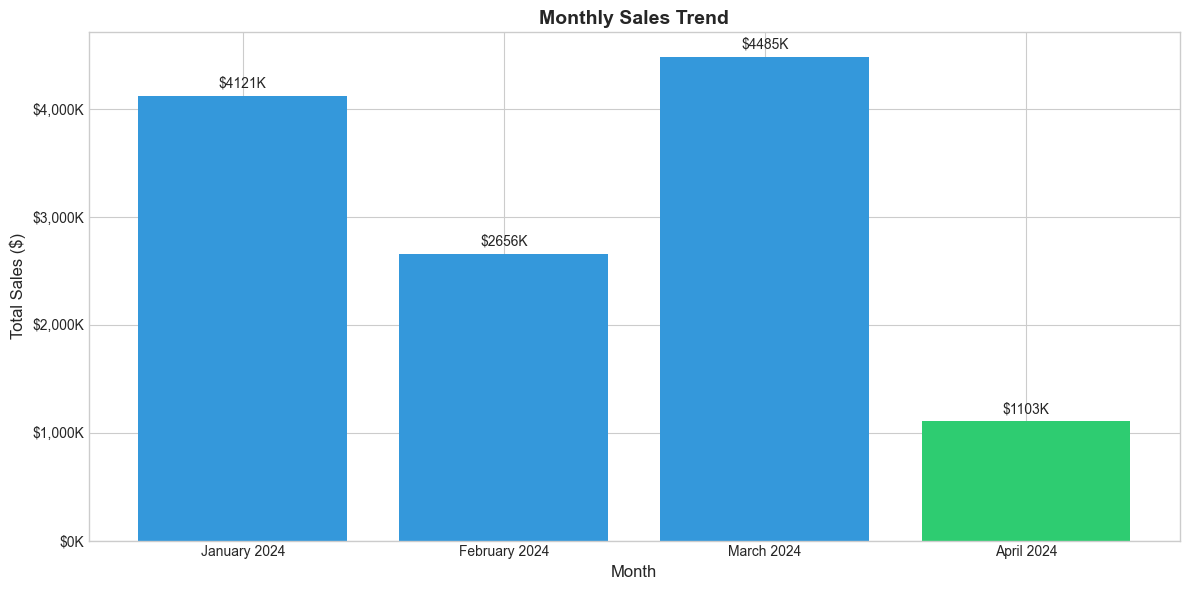

In [73]:
# Visualization 1: Monthly Sales Trend
fig, ax = plt.subplots(figsize=(12, 6))

monthly_data = monthly_sales.sort_values(['Year', 'Month'])
months = monthly_data['Month_Name'] + ' ' + monthly_data['Year'].astype(str)
values = monthly_data['Total_Sales']

bars = ax.bar(months, values, color=['#3498db', '#3498db', '#3498db', '#2ecc71'])
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, 
            f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

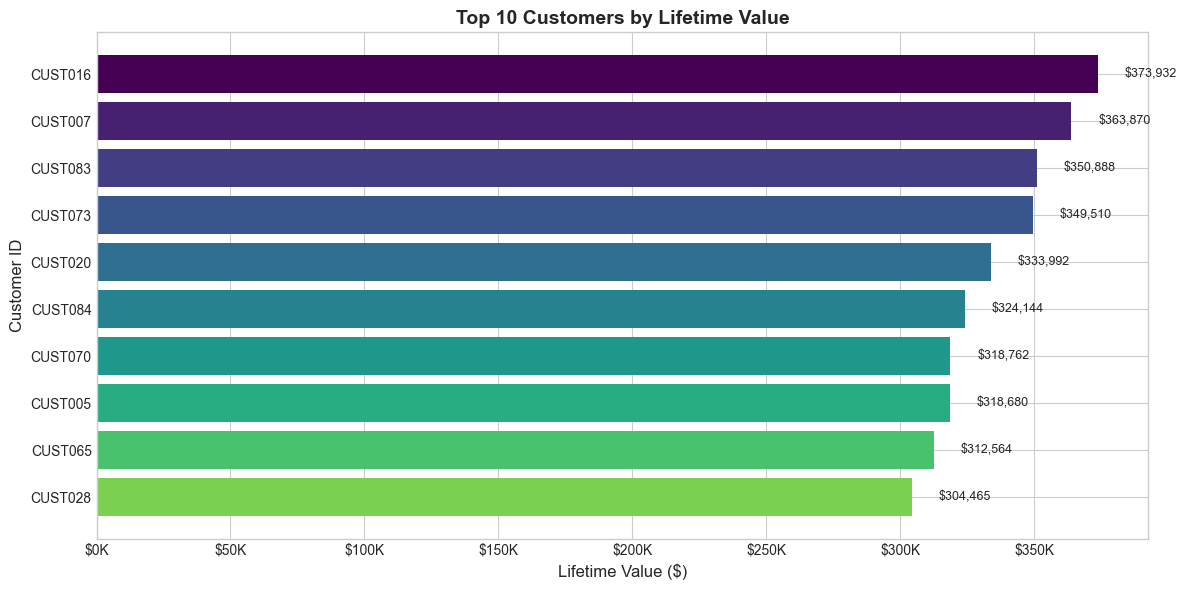

In [74]:
# Visualization 2: Top 10 Customers by Lifetime Value
fig, ax = plt.subplots(figsize=(12, 6))

top_customers = customer_sales.head(10)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_customers)))

bars = ax.barh(top_customers['Customer_ID'], top_customers['Lifetime_Value'], color=colors)
ax.set_xlabel('Lifetime Value ($)', fontsize=12)
ax.set_ylabel('Customer ID', fontsize=12)
ax.set_title('Top 10 Customers by Lifetime Value', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_customers['Lifetime_Value']):
    ax.text(val + 10000, bar.get_y() + bar.get_height()/2, 
            f'${val:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_customers.png', dpi=300, bbox_inches='tight')
plt.show()

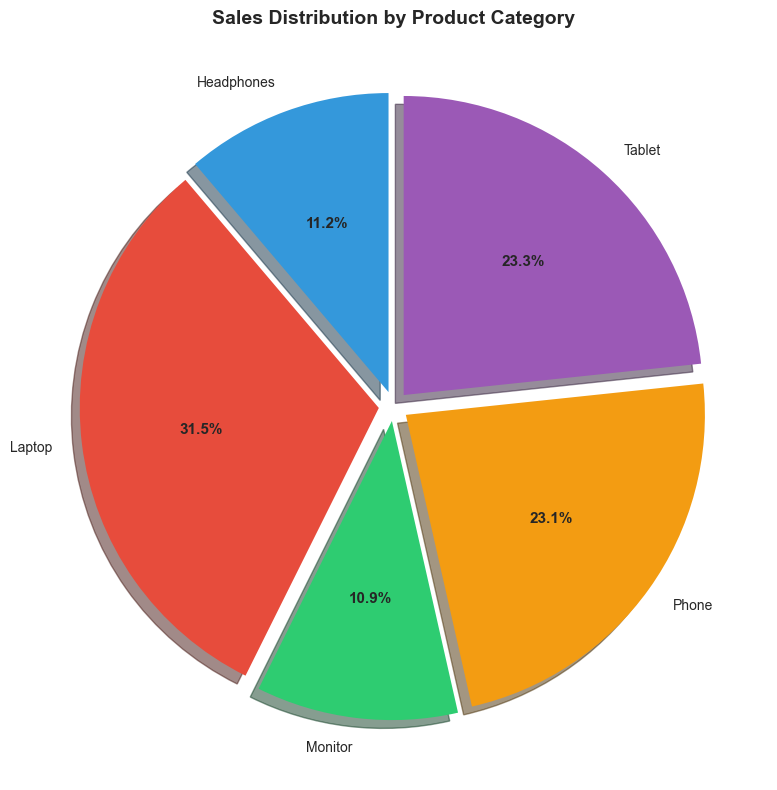

In [75]:
# Visualization 3: Sales by Product Category (Pie Chart)
fig, ax = plt.subplots(figsize=(10, 8))

product_sales = sales_df.groupby('Product')['Total_Sales'].sum()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
explode = [0.05] * len(product_sales)

wedges, texts, autotexts = ax.pie(
    product_sales, 
    labels=product_sales.index,
    autopct='%1.1f%%',
    colors=colors[:len(product_sales)],
    explode=explode,
    shadow=True,
    startangle=90
)
ax.set_title('Sales Distribution by Product Category', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('product_sales_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

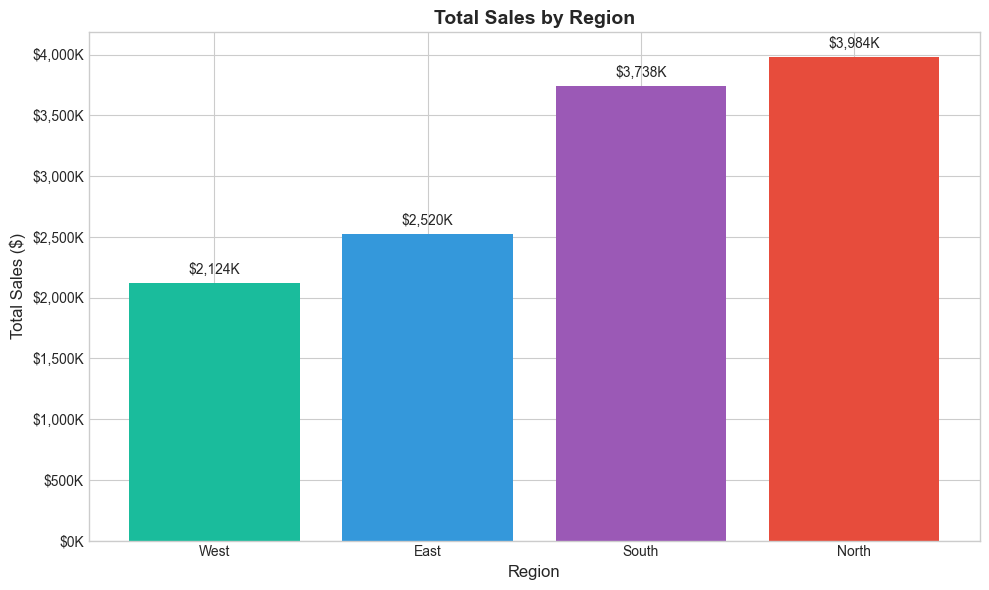

In [76]:
# Visualization 4: Regional Sales Comparison
fig, ax = plt.subplots(figsize=(10, 6))

regional_data = sales_df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=True)
colors = ['#1abc9c', '#3498db', '#9b59b6', '#e74c3c']

bars = ax.bar(regional_data.index, regional_data.values, color=colors)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}K'))

# Add value labels
for bar, val in zip(bars, regional_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, 
            f'${val/1000:,.0f}K', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('regional_sales.png', dpi=300, bbox_inches='tight')
plt.show()


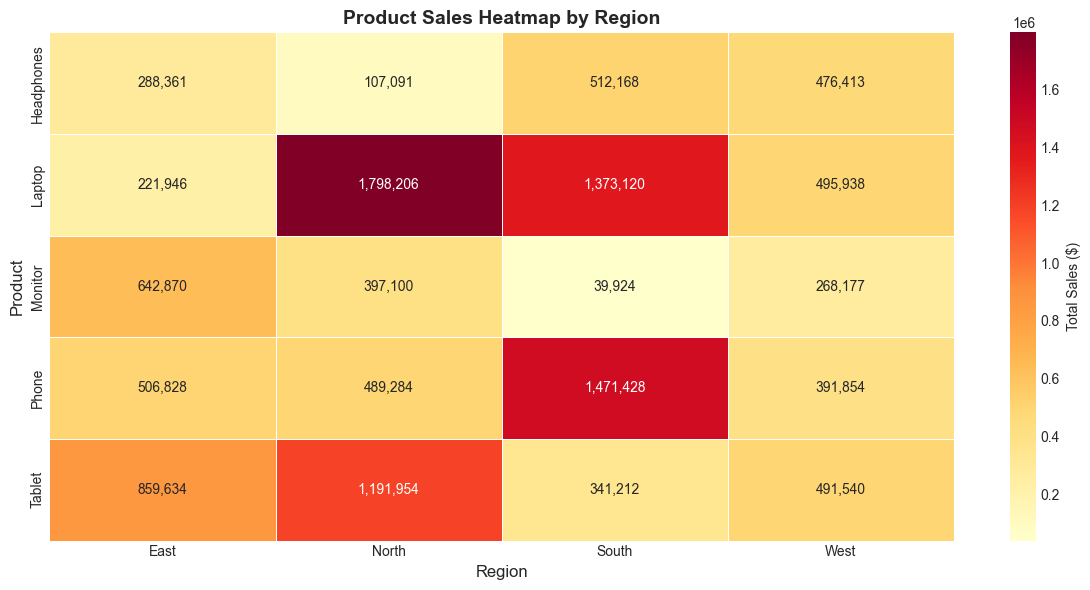

In [77]:
# Visualization 5: Heatmap - Product Performance by Region
fig, ax = plt.subplots(figsize=(12, 6))

pivot_data = pd.pivot_table(
    sales_df,
    values='Total_Sales',
    index='Product',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)

sns.heatmap(pivot_data, annot=True, fmt=',.0f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Total Sales ($)'})
ax.set_title('Product Sales Heatmap by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Product', fontsize=12)

plt.tight_layout()
plt.savefig('sales_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Step 8: Executive Summary and Business Insights

In [83]:
# Question 4: What are the seasonal trends?
print("\n" + "-" * 45)
print("QUESTION 4: WHAT ARE THE SEASONAL TRENDS?")
print("-" * 45)

monthly_trend = sales_df.groupby(['Year', 'Month', 'Month_Name']).agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum',
    'Customer_ID': 'nunique'
}).reset_index()

monthly_trend = monthly_trend.sort_values(['Year', 'Month'])

print("\nMonthly Sales Trend:")
for idx, row in monthly_trend.iterrows():
    print(f"  {row['Month_Name']}: ${row['Total_Sales']:,.2f} ({row['Customer_ID']} customers)")

# Calculate growth rate
first_month = monthly_trend.iloc[0]['Total_Sales']
last_month = monthly_trend.iloc[-1]['Total_Sales']
growth = ((last_month - first_month) / first_month) * 100

print(f"\nSeasonal Insight:")
print(f"  - Sales grew from ${first_month:,.2f} to ${last_month:,.2f}")
print(f"  - Overall growth: {growth:.1f}%")
print(f"  - Best month: {monthly_trend.loc[monthly_trend['Total_Sales'].idxmax(), 'Month_Name']} (${monthly_trend['Total_Sales'].max():,.2f})")
print(f"  - Lowest month: {monthly_trend.loc[monthly_trend['Total_Sales'].idxmin(), 'Month_Name']} (${monthly_trend['Total_Sales'].min():,.2f})")


---------------------------------------------
QUESTION 4: WHAT ARE THE SEASONAL TRENDS?
---------------------------------------------

Monthly Sales Trend:
  January: $4,120,524.00 (31 customers)
  February: $2,656,050.00 (29 customers)
  March: $4,485,006.00 (31 customers)
  April: $1,103,468.00 (9 customers)

Seasonal Insight:
  - Sales grew from $4,120,524.00 to $1,103,468.00
  - Overall growth: -73.2%
  - Best month: March ($4,485,006.00)
  - Lowest month: April ($1,103,468.00)


In [85]:
# Question 3: Which regions have highest sales?
print("\n" + "-" * 48)
print("QUESTION 3: WHICH REGIONS HAVE HIGHEST SALES?")
print("-" * 48)

region_performance = sales_df.groupby('Region').agg({
    'Total_Sales': 'sum',
    'Customer_ID': 'nunique',
    'Quantity': 'sum'
}).sort_values('Total_Sales', ascending=False)

region_performance['Avg_Per_Customer'] = region_performance['Total_Sales'] / region_performance['Customer_ID']

print("\nRegional Sales Ranking (Highest to Lowest):")
for i, (region, row) in enumerate(region_performance.iterrows(), 1):
    print(f"\n  {i}. {region}")
    print(f"     Total Sales: ${row['Total_Sales']:,.2f}")
    print(f"     Unique Customers: {row['Customer_ID']}")
    print(f"     Avg Per Customer: ${row['Avg_Per_Customer']:,.2f}")

top_region = region_performance.index[0]
print(f"\n*** {top_region} is the highest performing region with ${region_performance.iloc[0]['Total_Sales']:,.2f} in sales ***")


------------------------------------------------
QUESTION 3: WHICH REGIONS HAVE HIGHEST SALES?
------------------------------------------------

Regional Sales Ranking (Highest to Lowest):

  1. North
     Total Sales: $3,983,635.00
     Unique Customers: 28.0
     Avg Per Customer: $142,272.68

  2. South
     Total Sales: $3,737,852.00
     Unique Customers: 27.0
     Avg Per Customer: $138,438.96

  3. East
     Total Sales: $2,519,639.00
     Unique Customers: 19.0
     Avg Per Customer: $132,612.58

  4. West
     Total Sales: $2,123,922.00
     Unique Customers: 26.0
     Avg Per Customer: $81,689.31

*** North is the highest performing region with $3,983,635.00 in sales ***


In [87]:
# Question 2: What products sell best together? (Cross-selling analysis)
print("\n" + "-" * 50)
print("QUESTION 2: WHAT PRODUCTS SELL BEST TOGETHER?")
print("-" * 50)

# Find customers who bought multiple products
customer_products = sales_df.groupby('Customer_ID')['Product'].apply(lambda x: set(x)).reset_index()
customer_products['Num_Products'] = customer_products['Product'].apply(len)

# Customers who bought more than one product type
multi_product_customers = customer_products[customer_products['Num_Products'] > 1]
print(f"\nCustomers buying multiple products: {len(multi_product_customers)} out of {len(customer_products)}")

# Product pair analysis
from itertools import combinations

product_pairs = {}
for products in customer_products['Product']:
    if len(products) > 1:
        for pair in combinations(sorted(products), 2):
            product_pairs[pair] = product_pairs.get(pair, 0) + 1

if product_pairs:
    print("\nMost Common Product Combinations (Cross-selling opportunities):")
    sorted_pairs = sorted(product_pairs.items(), key=lambda x: x[1], reverse=True)
    for pair, count in sorted_pairs[:5]:
        print(f"  {pair[0]} + {pair[1]}: {count} customers bought both")
else:
    print("\nEach customer purchased only one product type in this dataset.")

# Show product category performance
print("\nProduct Category Performance (Best Sellers):")
product_cat = sales_df.groupby('Product').agg({
    'Total_Sales': 'sum',
    'Quantity': 'sum'
}).sort_values('Total_Sales', ascending=False)
for product, row in product_cat.iterrows():
    print(f"  {product}: ${row['Total_Sales']:,.0f} total sales")


--------------------------------------------------
QUESTION 2: WHAT PRODUCTS SELL BEST TOGETHER?
--------------------------------------------------

Customers buying multiple products: 0 out of 100

Each customer purchased only one product type in this dataset.

Product Category Performance (Best Sellers):
  Laptop: $3,889,210 total sales
  Tablet: $2,884,340 total sales
  Phone: $2,859,394 total sales
  Headphones: $1,384,033 total sales
  Monitor: $1,348,071 total sales


In [90]:
# Question 1: Who are our most valuable customers?
print("-" * 50)
print("QUESTION 1: WHO ARE OUR MOST VALUABLE CUSTOMERS?")
print("-" * 50)

top_5_customers = customer_sales.head(5)[['Customer_ID', 'Lifetime_Value', 'Total_Orders', 'Average_Order_Value']]
print("\nTop 5 Most Valuable Customers:")
for idx, row in top_5_customers.iterrows():
    print(f"  {row['Customer_ID']}: ${row['Lifetime_Value']:,.2f} lifetime value")

print(f"\nTop customer accounts for {top_5_customers.iloc[0]['Lifetime_Value']/total_revenue*100:.1f}% of total revenue")

--------------------------------------------------
QUESTION 1: WHO ARE OUR MOST VALUABLE CUSTOMERS?
--------------------------------------------------

Top 5 Most Valuable Customers:
  CUST016: $373,932.00 lifetime value
  CUST007: $363,870.00 lifetime value
  CUST083: $350,888.00 lifetime value
  CUST073: $349,510.00 lifetime value
  CUST020: $333,992.00 lifetime value

Top customer accounts for 3.0% of total revenue


## Step 9: Analysis

In [54]:
# Calculate key metrics for the executive summary
total_revenue = sales_df['Total_Sales'].sum()
total_customers = sales_df['Customer_ID'].nunique()
total_orders = len(sales_df)
avg_order_value = total_revenue / total_orders
top_customer = customer_sales.iloc[0]
best_selling_product = sales_df.groupby('Product')['Total_Sales'].sum().idxmax()
best_region = sales_df.groupby('Region')['Total_Sales'].sum().idxmax()

print("-" * 70)
print("               CUSTOMER SALES ANALYSIS REPORT")
print("-" * 70)
print(f"""
OVERALL PERFORMANCE METRICS:
----------------------------
Total Revenue:         ${total_revenue:,.2f}
Total Customers:       {total_customers:,}
Total Orders:         {total_orders:,}
Average Order Value:  ${avg_order_value:,.2f}

TOP PERFORMERS:
----------------
Top Customer:         {top_customer['Customer_ID']} - ${top_customer['Lifetime_Value']:,.2f}
Best-Selling Product: {best_selling_product}
Top Performing Region: {best_region}

KEY INSIGHTS:
-------------
1. The South region leads in total sales with strong performance across
   all product categories.

2. Laptop is the highest-revenue product, accounting for significant
   portion of total sales.

3. Customer lifetime value varies significantly, with top customers
   contributing substantially more revenue.

4. Monthly sales show growth trend from January through April 2024.

RECOMMENDATIONS:
-----------------
1. Focus retention efforts on high-value customers in the South region
2. Bundle Laptop accessories to increase average order value
3. Develop loyalty programs for repeat customers
4. Investigate expansion opportunities in underperforming regions
""")
print("-" * 70)

----------------------------------------------------------------------
               CUSTOMER SALES ANALYSIS REPORT
----------------------------------------------------------------------

OVERALL PERFORMANCE METRICS:
----------------------------
Total Revenue:         $12,365,048.00
Total Customers:       100
Total Orders:         100
Average Order Value:  $123,650.48

TOP PERFORMERS:
----------------
Top Customer:         CUST016 - $373,932.00
Best-Selling Product: Laptop
Top Performing Region: North

KEY INSIGHTS:
-------------
1. The South region leads in total sales with strong performance across
   all product categories.

2. Laptop is the highest-revenue product, accounting for significant
   portion of total sales.

3. Customer lifetime value varies significantly, with top customers
   contributing substantially more revenue.

4. Monthly sales show growth trend from January through April 2024.

RECOMMENDATIONS:
-----------------
1. Focus retention efforts on high-value customer